# <u>Classification and **Regression** Trees (CART)</u>

### Prerequisites:
* <a href="../../Supervised ML Basis.ipynb">Check out the notebook on Supervised ML Basics</a>


## Topics

* [1. Core idea](#idea)
* [2. Tree Structure](#structure)
* [3. How CART makes predictions](#predict)
* [4. Mathematical view](#math)
* [5. How Trees are built (Training)](#train)
* [6. Splitting criteria](#split)
    * [**6.1 Regression**](#reg)
    * [6.2 Classification](#class)
        * <a href="../../2.Classification/6.Descision Trees Classifier/Descision Trees Classifier.ipynb">Check out the notebook on Decision Tree Classifier</a>

* [7. Handling Features](#features)
    * [7.1 Numerical features](#numerical)
    * [7.2 Categorical features](#categorical)
    * [7.3 Missing values](#nas)
    * [7.4 Transformations](#trafo)


* [8. Overfitting problem](#overfitting)
* [9. Controlling Tree size](#size)
    * [9.1 Stopping criteria (pre-pruning)](#pre)
    * [9.2 Pruning (post-pruning)](#post)

* [10. Advantages](#adv)
* [11. Disadvantages](#disadv)
* [12. Practical use](#use)
* [13. Key Takeaway](#takeaway)
* [14. Descision Regression Tree library](#library)
    

    

In [3]:
import numpy as np # for rnadom number, linear algebra and general mathematic operations
import pandas as pd # for creating and working with dataframe
from matplotlib import pyplot as plt # for plotting in 2d
import plotly.express as px # for plotting in 3d
import plotly.graph_objects as go # for plotting in 3d
print("Setup complete")

Setup complete


<a class="anchor" id="idea"></a>
# 1. Core idea

- CART models are decision trees that split the feature space into regions.
- Each region (leaf) gives a constant prediction:
    - Classification $\rightarrow$ class label or probabilities
    - **Regression $\rightarrow$ numeric value**
- Trees model:
    - Non-linear relationships
    - Feature interactions
    - Are interpretable



<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree.png" width="500"/>
  <img src="pics/binary_tree2.png" width="500"/>
</div>

In [4]:
class BinaryTreeNode:
    def __init__(self,value):
        self.left = None
        self.right = None
        self.value = value
        self.depth=1


    def insert(self, value):
        if value > self.value:
            if self.right is None:
                self.right = BinaryTreeNode(value)
                self.depth += 1
            else:
                self.right.insert(value)  
        else:
            if self.left is None:
                self.left = BinaryTreeNode(value)
                self.depth += 1
            else:
                self.left.insert(value)

    def inorder(self):
        if self.left:
            self.left.inorder()

        print(self.value)

        if self.right:
            self.right.inorder()

    def preorder(self):
        print(self.value)

        if self.left:
            self.left.preorder()

        if self.right:
            self.right.preorder()


    def postorder(self):
        if self.left:
            self.left.postorder()

        if self.right:
            self.right.postorder()

        print(self.value)

    def find(self, x):
        if self.value == x:
            return True
        
        elif x < self.value:   # go LEFT
            if self.left is None:
                return False
            else:
                return self.left.find(x)

        else:  
            if self.right is None:
                return False
            else:
                return self.right.find(x)



root = BinaryTreeNode(24)
root.insert(33)
root.insert(12)
root.insert(5)
root.insert(112)
root.insert(26)
root.insert(0)
root.inorder()

print("Tree depth",root.depth)
print(root.find(6))
print(root.find(5))

0
5
12
24
26
33
112
Tree depth 3
False
True


<a class="anchor" id="structure"></a>
# 2. Tree Structure

A tree consists of:
- Root node $\rightarrow$ contains all data
- Internal nodes $\rightarrow$ apply splits
- Leaf nodes (terminal nodes) $\rightarrow$ make predictions ( class label and or probabilities)


Each split:
- Uses one feature + threshold
- Divides data into left/right child nodes

<p align="center">
<img src="pics/binary_tree_3.png" width="600"/>
</p>



<a class="anchor" id="predict"></a>
# 3. How CART makes predictions

- A new observation is passed down the tree using split rules
- It ends in exactly one leaf
- Output:
    - Classification $\rightarrow$ class or probabilities
    <p align="center">
    <img src="pics/binary_tree_4.png" width="700"/>
    </p>

    <p align="center">
    <img src="pics/binary_tree_5.png" width="700"/>
    </p>
    

    
    - Regression $\rightarrow$ numeric value

    <p align="center">
    <img src="pics/binary_tree_6.png" width="700"/>
    </p>



Trees can also be seen as rule-based models (if-then rules).

<a class="anchor" id="math"></a>
# 4. Mathematical view

Trees partition the feature space $\mathcal{X} $ into rectangular regions $Q_m$:

$$
f(x)=\sum_{m=1}^M c_m \mathbb{I}(x \in Q_m)
$$

- Each region has a constant prediction $c_m$ (i.e., predicted numerical response, class label or class distribution) 
- A tree with $M$ leaf nodes define $M$ rectangular regions $Q_m$

<p align="center">
<img src="pics/binary_tree_7.png" width="700"/>
</p>

### Example: Numerical Features

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_36.jpeg" width="500"/>
  <img src="pics/binary_tree_37.jpeg" width="500"/>
</div>

<a class="anchor" id="train"></a>
# 5. How Trees are built (Training) 
- Start with a root node containing all data (empty tree)
- Built tree by using recursive greedy splitting  in the feature space to each node $\mathcal{N}$
- At each iteration:
    1. Try all features (one feature at a time) and all possible split points $t$ per feature $x_j$ of $\mathcal{N}$
    2. Choose the split that minimizes error (risk) $\mathcal{R}(\mathcal{N},j,t)$
    3. Distribute data to child nodes according to the best split
    4. Repeat on child nodes


<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_8.png" width="500"/>
  <img src="pics/binary_tree_9.png" width="500"/>
</div>

<p align="center">
<img src="pics/binary_tree_10.png" width="600"/>
</p>

### Finding best split

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_11.png" width="500"/>
  <img src="pics/binary_tree_12.png" width="500"/>
</div>


<p align="center">
<img src="pics/binary_tree_13.png" width="600"/>
</p>

<a class="anchor" id="split"></a>
# 6. Splitting criteria

<a class="anchor" id="reg"></a>
## **6.1 Regression**


- Minimize sum of squared errors (L2 loss)
$$
\mathcal{R}(\mathcal{N})=\sum_{(x,y) \in \mathcal{N}}(y-c_{\mathcal{N}})^2
$$
- Prediction for each child node $\mathcal{N}$ is mean of target values
$$
c_\mathcal{N} = \frac{1}{|\mathcal{N}|} \sum_{(x,y) \in \mathcal{N}} y, \quad |\mathcal{N}| \text{ being number of data points in} \mathcal{N}
$$



<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_14.png" width="500"/>
  <img src="pics/binary_tree_15.png" width="500"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_16.png" width="500"/>
  <img src="pics/binary_tree_17.png" width="500"/>
</div>

- $\mathcal{N} \subseteq \mathcal{D}$ is the data inside the current node
- $c_\mathcal{N}$ predcited constant for node $\mathcal{N}$
- Risk for a node is $\mathcal{R}(\mathcal{N})=\sum_{(x,y) \in \mathcal{N}} L(y,c_\mathcal{N})$ with optimal constant $c_{\mathcal{N}}=\underset{c}{\arg\min} \sum_{(x,y) \in \mathcal{N}} L(y,c)$
- A split $x_j \geq t$ divides a parent node $\mathcal{N}$ into $\mathcal{N}_1 = \{(x,y) \in \mathcal{N}: x_j < t\}$ and $\mathcal{N}_2 = \{(x,y) \in \mathcal{N}: x_j \geq t\}$
- Evaluate quality of split: $\mathcal{R}(\mathcal{N},j,t)=\mathcal{R}(\mathcal{N}_1)+\mathcal{R}(\mathcal{N}_2)=\sum_{(x,y) \in \mathcal{N}_1} L(y,c_{\mathcal{N}_1})+\sum_{(x,y) \in \mathcal{N}_2} L(y,c_{\mathcal{N}_2})$
- Find best split of $\mathcal{N}$ into $\mathcal{N}_1$ and $\mathcal{N}_2$ by solving $\underset{j,t}{\arg\min}\mathcal{R}(\mathcal{N},j,t)$
- Optional evaluate via reweighted average accounting for different children sizes: $\bar{\mathcal{R}}(\mathcal{N},j,t)=\frac{\mid \mathcal{N}_1 \mid}{\mid \mathcal{N} \mid} \bar{\mathcal{R}}(\mathcal{N}_1) + \frac{\mid \mathcal{N}_2 \mid}{\mid \mathcal{N} \mid} \bar{\mathcal{R}}(\mathcal{N}_2)$ 


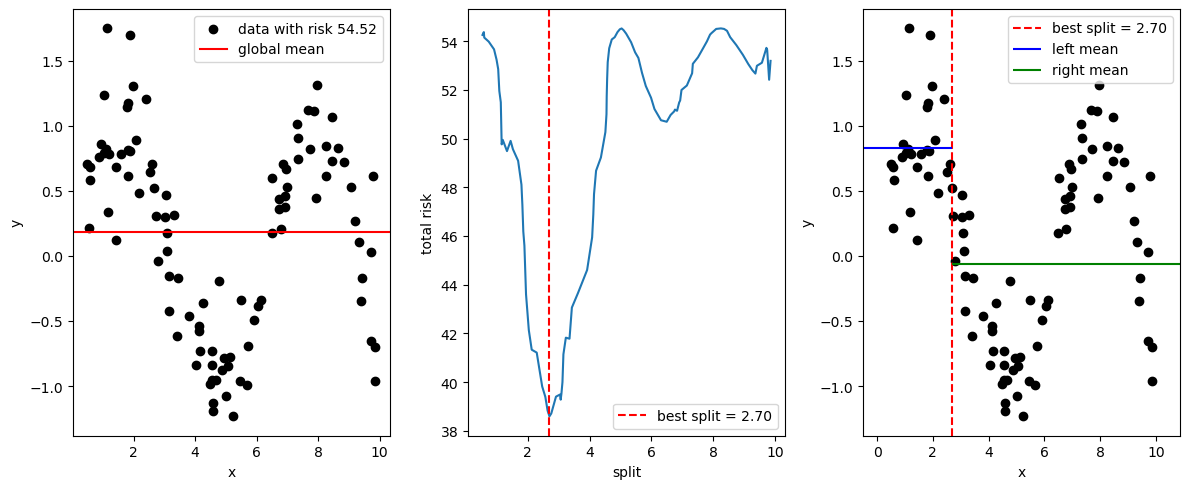

In [53]:
np.random.seed(1633) # for reproducibility
n = 100 # numer of data points

data = pd.DataFrame({"x": np.random.uniform(0, 10, n)})
target = pd.DataFrame({"y": np.sin(data.x) + np.random.normal(0, 0.3, n)})

y_global_mean = np.mean(target.y.values)

def node_risk(y):
    if len(y) == 0:
        return 0
    mean = np.mean(y)
    return np.sum((y - mean) ** 2)


def get_splits(x):
    x_sorted = np.sort(x)
    splits = (x_sorted[:-1] + x_sorted[1:]) / 2
    return splits


def find_best_split(x, y):
    splits = get_splits(x)

    best_split = None
    best_risk = float("inf")
    total_risk_list = []

    for t in splits:
        left_mask = x < t
        right_mask = x >= t

        y_left = y[left_mask]
        y_right = y[right_mask]

        risk_left = node_risk(y_left)
        risk_right = node_risk(y_right)

        total_risk = risk_left + risk_right
        total_risk_list.append(total_risk)

        if total_risk < best_risk:
            best_risk = total_risk
            best_split = t

    return best_split, best_risk, total_risk_list, splits


x = data.x.values
y = target.y.values

best_split, best_risk, total_risk_list, splits = find_best_split(x, y)

plt.figure(figsize=(12, 5))

# Plot data
plt.subplot(1, 3, 1)
plt.scatter(x, y, color="black",label=f"data with risk {node_risk(y):.2f}")
plt.axhline(y_global_mean, color="red", label="global mean")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

# Plot Risk vs split
plt.subplot(1, 3, 2)
plt.plot(splits, total_risk_list)
plt.axvline(best_split, color="red", linestyle="--",label=f"best split = {best_split:.2f}")
plt.xlabel("split")
plt.ylabel("total risk")
plt.legend()

# Plot best split
plt.subplot(1, 3, 3)
plt.scatter(x, y, color="black")
plt.axvline(best_split, color="red", linestyle="--", label=f"best split = {best_split:.2f}")

# means of each region
left_mean = np.mean(y[x < best_split])
right_mean = np.mean(y[x >= best_split])

plt.hlines(left_mean, xmin=min(x)-1, xmax=best_split, colors="blue", label="left mean")
plt.hlines(right_mean, xmin=best_split, xmax=max(x)+1, colors="green", label="right mean")

plt.xlabel("x")
plt.ylabel("y")
plt.xlim((min(x)-1,max(x)+1))
plt.legend()

plt.tight_layout()
plt.show()

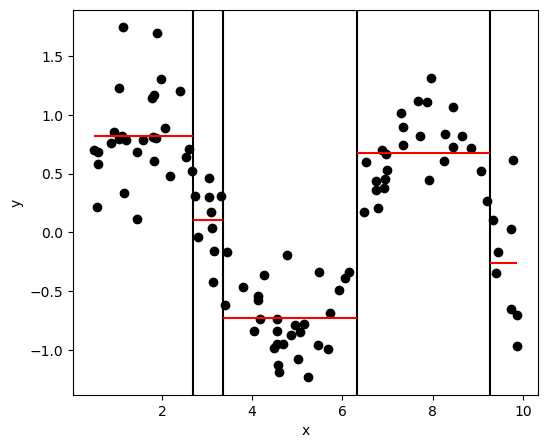

In [6]:
regions = [(min(x), max(x), np.arange(len(x)))] # a region [(xmin, xmax, indices)] is a rectangle

splits = []
region_means = []

min_samples = int(0.15 * len(y))

while True:
    best_global_split = None
    best_global_risk = float("inf")
    best_region_idx = None
    
    # try splitting each region
    for i, (xmin, xmax, idx) in enumerate(regions):
        
        if len(idx) < 2 * min_samples:
            continue
        
        x_region = x[idx]
        y_region = y[idx]
        
        best_split, best_risk, _, _ = find_best_split(x_region, y_region)
        
        if best_split is None:
            continue
        
        if best_risk < best_global_risk:
            best_global_risk = best_risk
            best_global_split = best_split
            best_region_idx = i
    
    # stop if no valid split found
    if best_global_split is None:
        break
    
    # split best region
    xmin, xmax, idx = regions.pop(best_region_idx)
    
    left_idx = idx[x[idx] < best_global_split]
    right_idx = idx[x[idx] >= best_global_split]
    
    regions.append((xmin, best_global_split, left_idx))
    regions.append((best_global_split, xmax, right_idx))
    
    splits.append(best_global_split)


for xmin, xmax, idx in regions:
    region_means.append((xmin, xmax, np.mean(y[idx])))

plt.figure(figsize=(6,5))
plt.scatter(x, y, color="black")

# vertical splits
for s in splits:
    plt.axvline(s, color="black")

# horizontal region means
for xmin, xmax, mean in region_means:
    plt.hlines(mean, xmin, xmax, colors="red")

plt.xlabel("x")
plt.ylabel("y")
plt.show()

Best feature: x2
Best split: 8.671052543853396
Best risk: 84.54363262670081
Risks per feature: {'x1': np.float64(90.23935317955947), 'x2': np.float64(84.54363262670081)}


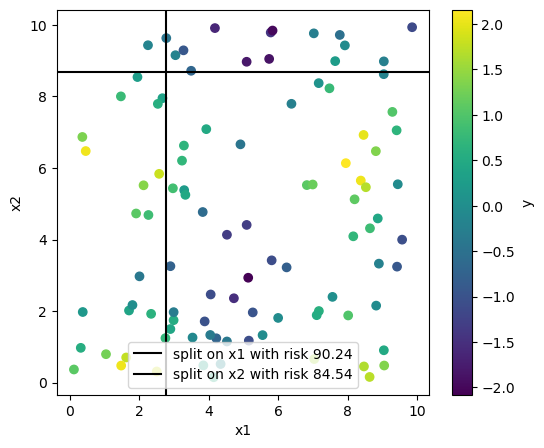

In [ ]:
np.random.seed(2019)
n = 100

data = pd.DataFrame({"x1": np.random.uniform(0, 10, n),"x2": np.random.uniform(0, 10, n)})

target = pd.DataFrame({"y": np.sin(data.x1) + np.cos(data.x2) + np.random.normal(0, 0.3, n)})

X = data.values
y = target.y.values


def find_best_split_2d(X, y):
    best_feature = None
    best_split = None
    best_risk = float("inf")

    n_features = X.shape[1]

    # store best risk per feature
    risks = {"x1": float("inf"), "x2": float("inf")}

    # store best split per feature
    best_splits = {"x1": None, "x2": None}

    for j in range(n_features):
        xj = X[:, j]
        candidate_splits = get_splits(xj)

        best_risk_feature = float("inf")
        best_split_feature = None

        for t in candidate_splits:
            left_mask = xj < t
            right_mask = xj >= t

            y_left = y[left_mask]
            y_right = y[right_mask]

            risk = node_risk(y_left) + node_risk(y_right)

            # best overall split
            if risk < best_risk:
                best_risk = risk
                best_split = t
                best_feature = j

            # best split for THIS feature
            if risk < best_risk_feature:
                best_risk_feature = risk
                best_split_feature = t

        # store per-feature results
        if j == 0:
            risks["x1"] = best_risk_feature
            best_splits["x1"] = best_split_feature
        else:
            risks["x2"] = best_risk_feature
            best_splits["x2"] = best_split_feature

    best_feature_name = "x1" if best_feature == 0 else "x2"

    return best_feature_name, best_split, best_risk, risks, best_splits


feature, split, risk, risks,splits = find_best_split_2d(X, y)

print("Best feature:", feature)
print("Best split:", split)
print("Best risk:", risk)
print("Risks per feature:", risks)


plt.figure(figsize=(6, 5))
plt.scatter(data.x1, data.x2, c=y, cmap="viridis")


plt.axvline(splits["x1"], color="black", label=f"split on x1 with risk {risks["x1"]:.2f}")
plt.axhline(splits["x2"], color="black", label=f"split on x2 with risk {risks["x2"]:.2f}")

plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="y")
plt.legend()
plt.show()

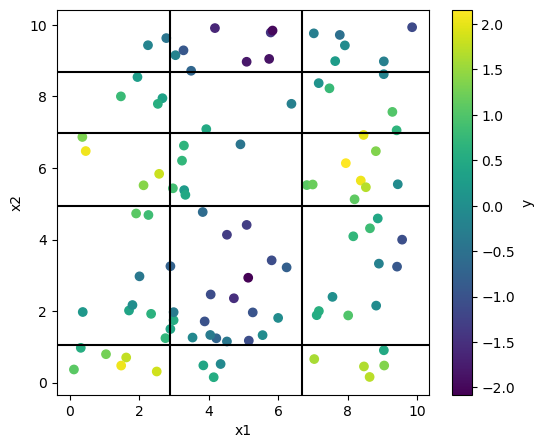

In [48]:
regions = [(min(X[:,0]), max(X[:,0]),
            min(X[:,1]), max(X[:,1]),
            np.arange(len(y)))] # a region is a rectangle (x1_min, x1_max, x2_min, x2_max, indices)

splits = [] # store (feature, split)
region_means = [] # store predictions per region

def find_best_split_2d(X, y):
    best_feature = None
    best_split = None
    best_risk = float("inf")
    
    for j in range(X.shape[1]):
        xj = X[:, j]
        splits = get_splits(xj)
        
        for t in splits:
            left = y[xj < t]
            right = y[xj >= t]
            
            risk = node_risk(left) + node_risk(right)
            
            if risk < best_risk:
                best_risk = risk
                best_split = t
                best_feature = j
    
    return best_feature, best_split, best_risk

min_samples = int(0.15 * len(y))

while True:
    best_global = None
    best_global_risk = float("inf")
    best_region_idx = None
    
    for i, (x1_min, x1_max, x2_min, x2_max, idx) in enumerate(regions):
        
        if len(idx) < 2 * min_samples:
            continue
        
        X_region = X[idx]
        y_region = y[idx]
        
        feature, split, risk = find_best_split_2d(X_region, y_region)
        
        if feature is None:
            continue
        
        if risk < best_global_risk:
            best_global = (feature, split)
            best_global_risk = risk
            best_region_idx = i
    
    if best_global is None:
        break
    
    feature, split = best_global
    
    # split region
    x1_min, x1_max, x2_min, x2_max, idx = regions.pop(best_region_idx)
    
    if feature == 0:
        left_idx = idx[X[idx, 0] < split]
        right_idx = idx[X[idx, 0] >= split]
        
        regions.append((x1_min, split, x2_min, x2_max, left_idx))
        regions.append((split, x1_max, x2_min, x2_max, right_idx))
    
    else:
        left_idx = idx[X[idx, 1] < split]
        right_idx = idx[X[idx, 1] >= split]
        
        regions.append((x1_min, x1_max, x2_min, split, left_idx))
        regions.append((x1_min, x1_max, split, x2_max, right_idx))
    
    splits.append((feature, split))

for x1_min, x1_max, x2_min, x2_max, idx in regions:
    region_means.append((x1_min, x1_max, x2_min, x2_max, np.mean(y[idx])))

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis")

# draw splits
for feature, split in splits:
    if feature == 0:
        plt.axvline(split, color="black")
    else:
        plt.axhline(split, color="black")

plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="y")
plt.show()

<a class="anchor" id="class"></a>
## 6.2 Classification

- Common loss functions:

    - Brier score (Gini impurity):$L(y,\pi)=\sum_{k=1}^g (\pi_k - o_k(y))^2$
    - Log loss (entropy): $L(y,\pi)=-\sum_{k=1}^g o_k(y) \log(\pi_k)$
    - Misclassification error (MCE less preferred): $L(y,\hat{y})=\frac{1}{\mid \mathcal{N} \mid} \sum_{(x,y) \in \mathcal{N}} \mathbb{I}(y \neq \hat{y})$
    - Brier Score and Log loss pick up changes in class probabilities and produce purer nodes than MCE

$\quad$ where $c_\mathcal{N} = (\hat{\pi}_1^{\mathcal{N}},\ldots,\hat{\pi}_g^{\mathcal{N}})$ with $\hat{\pi}_k^{(\mathcal{N})}=\frac{1}{\mid\mathcal{N}\mid} \sum_{(x,y) \in \mathcal{N}} \mathbb{I}(y=k) \hspace{1 mm} \forall k \in \{ 1,\ldots,g\}$ and $g$ number of classes

- Goal:
    - Create pure nodes (mostly one class)

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_18.png" width="500"/>
  <img src="pics/binary_tree_19.png" width="500"/>
</div>

<p align="center">
<img src="pics/binary_tree_20.png" width="600"/>
</p>

- Gini impurity: $I(\mathcal{N})=\sum_{k=1}^g \hat{\pi}_k^{(\mathcal{N})}(1-\hat{\pi}_k^{(\mathcal{N})})$
- Entropy: $I(\mathcal{N})=-\sum_{k=1}^g \hat{\pi}_k^{(\mathcal{N})} \log(\hat{\pi}_k^{(\mathcal{N})})$



<a href="../../2.Classification/6.Descision Trees Classifier/Descision Trees Classifier.ipynb">Check out the notebook on Decision Tree Classifier for code</a>

<a class="anchor" id="features"></a>
# 7. Handling features

<a class="anchor" id="numerical"></a>
## 7.1 Numerical features

- Split using thresholds

### Example:

$$
\begin{array}{ccc}
Y & X_1 & X_2 \\
\hline
3 & 1 & 2 \\
4 & 2 & 3 \\
7 & 2 & 4 \\
9 & 5 & 4 \\
8 & 5 & 2
\end{array}
$$

#### 1. Candidate splits and tresholds per feature (split between sorted values)

$$
X_1=\{1,2,2,5,5\} \overset{\text{sort}}{\rightarrow} \{1,2,2,5,5\} \overset{\text{unique values}}{\longrightarrow} \{1,2,5\} \rightarrow \left\{ \frac{1+2}{2}, \frac{2+5}{2} \right\}=\{1.5,3.5\} \\
X_2=\{2,3,4,4,2\} \overset{\text{sort}}{\rightarrow} \{2,2,3,4,4\} \overset{\text{unique values}}{\longrightarrow} \{2,3,4\} \rightarrow \left\{ \frac{2+3}{2}, \frac{3+4}{2} \right\}=\{2.5,3.5\} 
$$

#### 2. Risk per Child node

**Loss function**

$\quad$ When splitting we distribute the data points according to the split and the trehold into two different subsets

$\quad$ $\quad$ - Left child node: $\mathcal{N}_1 = \{(x,y) \in \mathcal{N}: x_j < t\}$ <br>
$\quad$ $\quad$ - Right child node: $\mathcal{N}_1 = \{(x,y) \in \mathcal{N}: x_j \geq t\}$

For both child nodes compute the optimal constant (here we choose the median) $c_\mathcal{N}=\text{median}_y$ and then calculate the empirical risk for each feature and there respective tresholds: $\mathcal{R}(\mathcal{N},j,t)=\mathcal{R}(\mathcal{N}_1)+\mathcal{R}(\mathcal{N}_2)=\sum_{(x,y) \in \mathcal{N}_1} L(y,c_{\mathcal{N}_1})+\sum_{(x,y) \in \mathcal{N}_2} L(y,c_{\mathcal{N}_2})$ and as loss function choose the median absolute deviation $L(y,c_{\mathcal{N}_i})=\sum_{(x,y) \in \mathcal{N}_i} \mid y - c_{\mathcal{N}_i}\mid$ for $i=1,2$

$X_j = X_1 \text{ with } t=1.5$
$$
\begin{align*}
X_1 < 1.5 \rightarrow Y = 3 &\Rightarrow c_{\mathcal{N}_1} = \text{median}_y = 3 \\
X_1 \geq 1.5 \rightarrow Y = \{4,7,8,9\} &\Rightarrow c_{\mathcal{N}_2}=\text{median}_y = 7.5 \\ 
\end{align*}
$$
$$
\begin{align*}
&\mathcal{R}(\mathcal{N}_1) = \mid 3 - 3 \mid = 0 \\
&\mathcal{R}(\mathcal{N}_2) = \mid 4-7.5 \mid + \mid 7-7.5 \mid + \mid 9-7.5 \mid + \mid 8-7.5 \mid = 6 \\
&\mathcal{R}(\mathcal{N},1,1.5)=\mathcal{R}(\mathcal{N}_1)+ \mathcal{R}(\mathcal{N}_2) = 6
\end{align*}
$$

$X_j = X_1 \text{ with } t=3.5$
$$
\begin{align*}
X_1 < 3.5 \rightarrow Y = \{3,4,7\} &\Rightarrow c_{\mathcal{N}_1} = \text{median}_y = 4 \\
X_1 \geq 3.5 \rightarrow Y = \{8,9\} &\Rightarrow c_{\mathcal{N}_2}=\text{median}_y = 8.5 \\ 
\end{align*}
$$
$$
\begin{align*}
&\mathcal{R}(\mathcal{N}_1) = \mid 3 - 4 \mid + \mid 4 - 4 \mid + \mid 7 - 4 \mid = 4 \\
&\mathcal{R}(\mathcal{N}_2) = \mid 9-8.5 \mid + \mid 8-8.5 \mid  = 1 \\
&\mathcal{R}(\mathcal{N},1,3.5)=\mathcal{R}(\mathcal{N}_1)+ \mathcal{R}(\mathcal{N}_2) = 5
\end{align*}
$$

---

$X_j = X_2 \text{ with } t=2.5$
$$
\begin{align*}
X_2 < 2.5 \rightarrow Y = \{3,8\} &\Rightarrow c_{\mathcal{N}_1} = \text{median}_y = 5.5 \\
X_2 \geq 2.5 \rightarrow Y = \{4,7,9\} &\Rightarrow c_{\mathcal{N}_2}=\text{median}_y = 7 \\ 
\end{align*}
$$
$$
\begin{align*}
&\mathcal{R}(\mathcal{N}_1) = \mid 3 - 5.5 \mid + \mid 8 - 5.5 \mid = 5 \\
&\mathcal{R}(\mathcal{N}_2) = \mid 4-7 \mid + \mid 7-7 \mid + \mid 9-7 \mid  = 5 \\
&\mathcal{R}(\mathcal{N},2,2.5)=\mathcal{R}(\mathcal{N}_1)+ \mathcal{R}(\mathcal{N}_2) = 10
\end{align*}
$$

$X_j = X_2 \text{ with } t=3.5$
$$
\begin{align*}
X_2 < 3.5 \rightarrow Y = \{3,4,8\} &\Rightarrow c_{\mathcal{N}_1} = \text{median}_y = 4 \\
X_2 \geq 3.5 \rightarrow Y = \{7,9\} &\Rightarrow c_{\mathcal{N}_2}=\text{median}_y = 8 \\ 
\end{align*}
$$
$$
\begin{align*}
&\mathcal{R}(\mathcal{N}_1) = \mid 3 - 4 \mid + \mid 4 - 4 \mid + \mid 8 - 4 \mid = 5 \\
&\mathcal{R}(\mathcal{N}_2) = \mid 7-8 \mid + \mid 9-8 \mid  = 2 \\
&\mathcal{R}(\mathcal{N},2,3.5)=\mathcal{R}(\mathcal{N}_1)+ \mathcal{R}(\mathcal{N}_2) = 7
\end{align*}
$$

$$
\left.
\begin{array}{rcl}
X_1=1.5 & \Rightarrow  & \mathcal{R}(\mathcal{N},1,1.5)=6 \\
X_1=3.5 & \Rightarrow  & \mathcal{R}(\mathcal{N},1,3.5)=5 \\
X_2=2.5 & \Rightarrow & \mathcal{R}(\mathcal{N},2,2.5)=10 \\
X_2=3.5 & \Rightarrow & \mathcal{R}(\mathcal{N},2,3.5)=7 \\
\end{array}
\right\} \underset{j,t}{\arg\min} = (j=1,t=3.5) 
$$
So the first optimal split is: $X_1 < 3.5$ vs. $X_1 \geq 3.5$

<a class="anchor" id="categorical"></a>
## 7.2 Categorical features

- Partition categories into two groups
- Optimization trick: Sort categories by target statistics

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_22.png" width="500"/>
  <img src="pics/binary_tree_22.1.png" width="600"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_23.png" width="500"/>
  <img src="pics/C.png" width="500"/>
</div>

### Example: 

$$
\begin{array}{ccc}
Y & X_1 \\
\hline
1 & A  \\
1 & B  \\
1 & C  \\
1 & C  \\
1 & C \\
0 & B \\
0 & B \\
0 & C \\
\end{array}
$$

#### 1. Candidate splits and tresholds per feature (split between sorted values)

$\quad$ Relative frequency of observations in class $Y=1$

$\quad$ $\quad$ - A:$\frac{1}{1}=1$ $\rightarrow$ There is in total one observation A and it is in class 1<br>

$\quad$ $\quad$ - B: $\frac{1}{3}$ $\rightarrow$ There are in total three observations B and one is in class 1 <br>

$\quad$ $\quad$ - C: $\frac{3}{4}$ $\rightarrow$ There are in total four observations B and three are in class 1

$\quad$ Sort by categories by relative frequency: $\overbrace{\frac{1}{3}}^{B} < \overbrace{\frac{3}{4}}^{C} < \overbrace{1}^{A}$

$\quad$ Candidate splits: $\{B\}$ vs. $\{C,A\}$ and $\{B,c\}$ vs. $\{A\}$

#### 2. Risk per Child node

**Loss function**

$\quad$ Weighted Gini impurity for $0-1$ (binary) response

$$
\begin{align*}
\mathcal{R}(\mathcal{N}, j, t) 
&= \mathcal{R}(\mathcal{N}_1, j, t) + \mathcal{R}(\mathcal{N}_2, j, t) \\ 
&= \frac{\mid \mathcal{N}_1 \mid}{\mid \mathcal{N} \mid} \cdot 2 \cdot p_{\mathcal{N}_1}(0) \cdot p_{\mathcal{N}_1}(1) +
\frac{\mid \mathcal{N}_2 \mid}{\mid \mathcal{N} \mid} \cdot 2 \cdot p_{\mathcal{N}_2}(0) \cdot p_{\mathcal{N}_2}(1)
\end{align*}
$$



$t=\{B\} \text{ vs. } \{C, A\}$
- $\mathcal{N}_1$ and $X_1=B$: 3 observations in total (1 in class 1 and 2 in class 0)
    - $p_{\mathcal{N}_1}(1) = \frac{1}{3}$ 
    - $p_{\mathcal{N}_1}(0) = \frac{2}{3}$
- $\mathcal{N}_2$ and $X_1 \in \{C,A\}$: 5 observations in total (4 in class 1 and 1 in class 0)
    - $p_{\mathcal{N}_1}(1) = \frac{4}{5}$ 
    - $p_{\mathcal{N}_1}(0) = \frac{1}{5}$

- $\mathcal{R}(\mathcal{N}, 1, \{B\}/\{C, A\}) = \frac{3}{8} \cdot 2 \cdot \frac{2}{3} \cdot \frac{1}{3} + \frac{5}{8} \cdot 2 \cdot \frac{1}{5} \cdot \frac{4}{5} \approx 0.37$


$t=\{B,C\} \text{ vs. } \{A\}$
- $\mathcal{N}_1$ and $X_1 \in \{B,C\}$: 7 observations in total (4 in class 1 and 3 in class 0)
    - $p_{\mathcal{N}_1}(1) = \frac{4}{7}$ 
    - $p_{\mathcal{N}_1}(0) = \frac{3}{7}$
- $\mathcal{N}_2$ and $X_1 = A$: 1 observation in total (1 in class 1 and 0 in class 0)
    - $p_{\mathcal{N}_1}(1) = \frac{1}{1}=1$ 
    - $p_{\mathcal{N}_1}(0) = \frac{0}{1}=0$

- $\mathcal{R}(\mathcal{N}, 1, \{B, C\}/\{A\}) = \frac{7}{8} \cdot 2 \cdot \frac{2}{7} \cdot \frac{4}{7} + \frac{1}{8} \cdot 2 \cdot 0 \cdot 1  = \frac{3}{7} \approx 0.43$


Since $\mathcal{R}(\mathcal{N}, 1, \{B\}/\{C, A\}) < \mathcal{R}(\mathcal{N}, 1, \{B, C\}/\{A\})$ the optimal first split is $\{B\} \text{ vs. } \{C, A\}$ 


<a class="anchor" id="nas"></a>
## 7.3 Missing values

- For distributing data points into child nodes only data points for which the used feature is not missing are considered
- Use **surrogate splits** (alternative rules) to also distribute these features
- Surrogate splits are created during the tree building and define a different splitting rule while using a different feature 
- These surrogate splits result in the same child nodes as the original splits
- While passing an obsrvation down the tree and the feature value used in a split is missing $\rightarrow$ Use surrogate split instead to distribute data points to a child node

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/A.png" width="500"/>
  <img src="pics/B.png" width="600"/>
</div>

<a class="anchor" id="trafo"></a>
## 7.4 Transformations

- Monotonic transformations don’t change the tree structure

<p align="center">
<img src="pics/binary_tree_21.png" width="600"/>
</p>

<a class="anchor" id="overfitting"></a>
# 8. Overfitting problem

- Fully grown trees:
    - Fit training data perfectly
    - Every leaf node contains a single observation
    - Generalize poorly (overfitting)

<p align="center">
<img src="pics/binary_tree_25.png" width="600"/>
</p>

<a class="anchor" id="size"></a>
# 9. Controlling Tree size

<p align="center">
<img src="pics/binary_tree_26.png" width="600"/>
</p>


<a class="anchor" id="pre"></a>
## 9.1 Stopping criteria (pre-pruning)

Stop splitting if:

- Certain number of leaves is reached
- Too few samples per leaf node
- No improvement in risk reduction in children compared to parent node 
- Node is pure
- Max depth reached
$\Rightarrow$ Selection of stopping criterion is a hyperparameter of CARTs

### Horizon effect

<p align="center">
<img src="pics/binary_tree_27.png" width="600"/>
</p>

<a class="anchor" id="post"></a>
## 9.2 Pruning (post-pruning)

- Grow a large tree, then cut it back so that the resulting smaller tree has lower risk
- Most important method: Cost-Complexity Pruning (CCP)

$$
\begin{align*}
\mathcal{R}_{\text{reg}}(T) 
&= \text{loss} + \alpha \cdot \text{number of leaves} \\
&= \sum_{m=1}^{\mid T \mid} \sum_{i:x^{(i)} \in Q_m} L(y^{(i)},c_m) + \alpha \mid T\mid
\end{align*}
$$

- $Q_m$ subset of feature space related to the $m$-th leaf node
- $c_m$ predictions for $Q_m$ of $m$-th leaf node
- $T_0$ is complete tree
- $\mid T \mid$ is number of leaves of sub tree $Q_m$
- For $\alpha=0$ we would select $T_0$ 
- $\alpha$ controls trade-off between:
    - Fit quality
    - Model complexity

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_28.png" width="500"/>
  <img src="pics/binary_tree_29.png" width="500"/>
</div>

---


<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_30.png" width="500"/>
  <img src="pics/binary_tree_31.png" width="500"/>
</div>

---


<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_32.png" width="500"/>
  <img src="pics/binary_tree_33.png" width="500"/>
</div>

- CCP performs a greed backward search
  - Fix $\alpha$ and compute $\mathcal{R}_\text{reg}(T)$ for all possible sub trees that can be created by replacing one internal node with a leaf
  - When replacing an internal also eliminate all subsequent nodes
  - Select subtree with lowest risk and repeat procedure
  - Stop if pruning does not reduce risk anymore
  - $\alpha$ is selected via cross-validation

<a class="anchor" id="adv"></a>
# 10. Advantages

- Easy to understand & interpret
- Handles:
    - Non-linearities
    - Interactions
    - Categorical data
    - Missing values

- No need for feature scaling
- Fast and flexible

<a class="anchor" id="disadv"></a>
# 11. Disadvantages

- High variance (unstable) $\rightarrow$ small data changes $\rightarrow$ different trees
- Poor at:
    - Modeling smooth relationships
    - Extrapolation
    - Capturing linear relationships efficiently

- Often lower predictive accuracy than other models

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="pics/binary_tree_34.png" width="500"/>
  <img src="pics/binary_tree_35.png" width="500"/>
</div>


<a class="anchor" id="use"></a>
# 12. Practical use

- Rarely used alone for best performance
- Commonly used in ensembles:
    - Random Forests
    - Bagging

- Still useful when:
    - Interpretability is important
    - Simple decision rules are needed

<a class="anchor" id="takeaway"></a>
# 13. Key Takeaway

CART builds interpretable models by recursively splitting data into regions, but needs regularization (pruning or ensembles) to avoid overfitting and instability.

<a class="anchor" id="library"></a>
# 14. Descision Regression Tree library